# Task 2 - Transformation + PCA + Discretization

## 2.1 Initial Preparation
1. Remove duplicate rows
2. Inspect and transform the Dt_Customer column


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("data_cleaned.csv")
df.head()

,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,AcceptedCmp2,Complain,Response,Total_Spending,Total_Purchases,Average_Spend,Family_Size,Age,Engagement,Spending_Ratio
0,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,...,0,0,1,1617,22,70.304348,1,69,0.372881,0.027813
1,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,...,0,0,0,27,4,5.400000,3,72,0.102564,0.000583
2,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,...,0,0,0,776,20,36.952381,1,61,0.740741,0.010836
3,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,...,0,0,0,53,6,7.571429,2,42,0.222222,0.001989
4,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,...,0,0,0,422,14,28.133333,2,45,0.147368,0.007239


####Removing Duplicates

In [3]:
print("Shape before removing duplicates:", df.shape)

Shape before removing duplicates: (2209, 32)


In [4]:
n_dupes = df.duplicated().sum()
print("Duplicate rows:", n_dupes)

Duplicate rows: 183


In [5]:
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (2026, 32)


In [6]:
n_dupes_after = df.duplicated().sum()
print("Duplicate rows:", n_dupes_after)

Duplicate rows: 0


####Inspect Dt_Customer Column

In [7]:
print("Dt_Customer exists:", "Dt_Customer" in df.columns)

if "Dt_Customer" in df.columns:
    print("\nData type:")
    print(df["Dt_Customer"].dtype)

    print("\nFirst 10 values:")
    print(df["Dt_Customer"].head(10))

Dt_Customer exists: True

Data type:
object

First 10 values:
0    2012-09-04
1    2014-03-08
2    2013-08-21
3    2014-02-10
4    2014-01-19
5    2013-09-09
6    2012-11-13
7    2013-05-08
8    2013-06-06
9    2014-03-13
Name: Dt_Customer, dtype: object


######Convert to datetime

In [8]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], errors="coerce")
df["Dt_Customer"].head()

0   2012-09-04
1   2014-03-08
2   2013-08-21
3   2014-02-10
4   2014-01-19
Name: Dt_Customer, dtype: datetime64[ns]

In [9]:
print("New data type:", df["Dt_Customer"].dtype)
print("Missing dates after conversion:", df["Dt_Customer"].isnull().sum())
print("Earliest date:", df["Dt_Customer"].min())
print("Latest date:", df["Dt_Customer"].max())

New data type: datetime64[ns]
Missing dates after conversion: 0
Earliest date: 2012-07-30 00:00:00
Latest date: 2014-06-29 00:00:00


Instead of keeping the date, I will convert it into a numeric feature.

###Customer_Days
The number of days the person has been a customer.

I will calculate this by taking the latest date in the dataset as and subtract each customer's enrollment date.

In [10]:
reference_date = df["Dt_Customer"].max()
df["Customer_Days"] = (reference_date - df["Dt_Customer"]).dt.days
df[["Dt_Customer", "Customer_Days"]].head()

,Dt_Customer,Customer_Days
0,2012-09-04,663
1,2014-03-08,113
2,2013-08-21,312
3,2014-02-10,139
4,2014-01-19,161


Besides customer duration, Those also could be extracted:
- enrollment year
- enrollment month

In [11]:
df["Customer_Year"] = df["Dt_Customer"].dt.year
df["Customer_Month"] = df["Dt_Customer"].dt.month

df[["Dt_Customer", "Customer_Days", "Customer_Year", "Customer_Month"]].head()

,Dt_Customer,Customer_Days,Customer_Year,Customer_Month
0,2012-09-04,663,2012,9
1,2014-03-08,113,2014,3
2,2013-08-21,312,2013,8
3,2014-02-10,139,2014,2
4,2014-01-19,161,2014,1


dropping the original Dt_Customer column

In [12]:
df = df.drop(columns=["Dt_Customer"])
df.head()

,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,Total_Spending,Total_Purchases,Average_Spend,Family_Size,Age,Engagement,Spending_Ratio,Customer_Days,Customer_Year,Customer_Month
0,Graduation,Single,58138.0,0,0,58,635,88,546,172,...,1617,22,70.304348,1,69,0.372881,0.027813,663,2012,9
1,Graduation,Single,46344.0,1,1,38,11,1,6,2,...,27,4,5.400000,3,72,0.102564,0.000583,113,2014,3
2,Graduation,Together,71613.0,0,0,26,426,49,127,111,...,776,20,36.952381,1,61,0.740741,0.010836,312,2013,8
3,Graduation,Together,26646.0,1,0,26,11,4,20,10,...,53,6,7.571429,2,42,0.222222,0.001989,139,2014,2
4,PhD,Married,58293.0,1,0,94,173,43,118,46,...,422,14,28.133333,2,45,0.147368,0.007239,161,2014,1


##2.2 Encoding

In [13]:
df.dtypes

Education               object
Marital_Status          object
Income                 float64
Kidhome                  int64
Teenhome                 int64
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Response                 int64
Total_Spending           int64
Total_Purchases          int64
Average_Spend          float64
Family_Size              int64
Age                      int64
Engagement             float64
Spending_Ratio         float64
Customer_Days            int64
Customer

In [14]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = df.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical columns:", categorical_cols)
print("Number of categorical columns:", len(categorical_cols))

print("\nNumeric columns:", numeric_cols)
print("Number of numeric columns:", len(numeric_cols))

Categorical columns: ['Education', 'Marital_Status']
Number of categorical columns: 2

Numeric columns: ['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response', 'Total_Spending', 'Total_Purchases', 'Average_Spend', 'Family_Size', 'Age', 'Engagement', 'Spending_Ratio', 'Customer_Days', 'Customer_Year', 'Customer_Month']
Number of numeric columns: 32


In [15]:
for col in categorical_cols:
    print(f"\n{col} unique values:")
    print(sorted(df[col].unique()))


Education unique values:
['2n Cycle', 'Basic', 'Graduation', 'Master', 'PhD']

Marital_Status unique values:
['Divorced', 'Married', 'Single', 'Together', 'Widow']


In [16]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=False)
df_encoded.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow
0,58138.0,0,0,58,635,88,546,172,88,88,...,False,False,True,False,False,False,False,True,False,False
1,46344.0,1,1,38,11,1,6,2,1,6,...,False,False,True,False,False,False,False,True,False,False
2,71613.0,0,0,26,426,49,127,111,21,42,...,False,False,True,False,False,False,False,False,True,False
3,26646.0,1,0,26,11,4,20,10,3,5,...,False,False,True,False,False,False,False,False,True,False
4,58293.0,1,0,94,173,43,118,46,27,15,...,False,False,False,False,True,False,True,False,False,False


In [17]:
print("Shape after encoding:", df_encoded.shape)
print("\nColumns after encoding:")
print(df_encoded.columns.tolist())

Shape after encoding: (2026, 42)

Columns after encoding:
['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response', 'Total_Spending', 'Total_Purchases', 'Average_Spend', 'Family_Size', 'Age', 'Engagement', 'Spending_Ratio', 'Customer_Days', 'Customer_Year', 'Customer_Month', 'Education_2n Cycle', 'Education_Basic', 'Education_Graduation', 'Education_Master', 'Education_PhD', 'Marital_Status_Divorced', 'Marital_Status_Married', 'Marital_Status_Single', 'Marital_Status_Together', 'Marital_Status_Widow']


In [18]:
print(df_encoded.dtypes.value_counts())

int64      26
bool       10
float64     4
int32       2
Name: count, dtype: int64


##2.3 Scaling

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [20]:
df_before_scaling = df_encoded.copy()

In [21]:
scaled_array = scaler.fit_transform(df_encoded)

df_scaled = pd.DataFrame(scaled_array, columns=df_encoded.columns)
df_scaled.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow
0,0.294256,-0.827840,-0.931748,0.314316,0.976676,1.556101,1.667802,2.467001,1.464565,0.863671,...,-0.315111,-0.157433,0.996059,-0.445093,-0.528243,-0.344556,-0.797816,1.898564,-0.582290,-0.189175
1,-0.264951,1.037793,0.899213,-0.376361,-0.871982,-0.635679,-0.713339,-0.647039,-0.630241,-0.731617,...,-0.315111,-0.157433,0.996059,-0.445093,-0.528243,-0.344556,-0.797816,1.898564,-0.582290,-0.189175
2,0.933167,-0.827840,-0.931748,-0.790767,0.357494,0.573579,-0.179787,1.349610,-0.148677,-0.031247,...,-0.315111,-0.157433,0.996059,-0.445093,-0.528243,-0.344556,-0.797816,-0.526714,1.717358,-0.189175
3,-1.198923,1.037793,-0.931748,-0.790767,-0.871982,-0.560100,-0.651606,-0.500496,-0.582085,-0.751072,...,-0.315111,-0.157433,0.996059,-0.445093,-0.528243,-0.344556,-0.797816,-0.526714,1.717358,-0.189175
4,0.301605,1.037793,-0.931748,1.557534,-0.392042,0.422422,-0.219473,0.158948,-0.004207,-0.556524,...,-0.315111,-0.157433,-1.003956,-0.445093,1.893069,-0.344556,1.253422,-0.526714,-0.582290,-0.189175


In [22]:
df_scaled.describe().T.head(10)

,count,mean,std,min,25%,50%,75%,max
Income,2026.0,-6.312818e-17,1.000247,-2.380304,-0.780940,-0.018917,0.784653,3.152666
Kidhome,2026.0,2.893375e-17,1.000247,-0.827840,-0.827840,-0.827840,1.037793,2.903427
Teenhome,2026.0,-6.663530e-17,1.000247,-0.931748,-0.931748,-0.931748,0.899213,2.730174
Recency,2026.0,5.699072e-17,1.000247,-1.688647,-0.859835,0.003511,0.866857,1.730203
MntWines,2026.0,-2.981053e-17,1.000247,-0.904571,-0.836431,-0.387598,0.595983,3.518581
MntFruits,2026.0,0.000000e+00,1.000247,-0.660871,-0.610486,-0.459329,0.170493,4.352510
MntMeatProducts,2026.0,0.000000e+00,1.000247,-0.739796,-0.669244,-0.439949,0.274394,6.866628
MntFishProducts,2026.0,7.540310e-17,1.000247,-0.683675,-0.628721,-0.463860,0.232219,4.060657
MntSweetProducts,2026.0,1.424768e-17,1.000247,-0.654320,-0.630241,-0.461694,0.158321,5.654179
MntGoldProds,2026.0,-2.454985e-17,1.000247,-0.848345,-0.673253,-0.381432,0.241120,5.396623


In [23]:
print("Shape after scaling:", df_scaled.shape)

Shape after scaling: (2026, 42)


In [24]:
df_scaled.to_csv("data_encoded_scaled.csv", index=False)
print("Saved as data_encoded_scaled.csv")

Saved as data_encoded_scaled.csv


##2.4 PCA

In [25]:
from sklearn.decomposition import PCA

In [26]:
pca_full = PCA()
pca_full.fit(df_scaled)

PCA()

In [27]:
explained_variance = pca_full.explained_variance_ratio_
print(explained_variance)

[2.32678628e-01 6.62102783e-02 5.60687861e-02 4.76389294e-02
 3.90153916e-02 3.70871392e-02 3.52064081e-02 3.15148019e-02
 3.13349713e-02 2.90249857e-02 2.81293499e-02 2.73855056e-02
 2.57351770e-02 2.56521561e-02 2.41579915e-02 2.35790649e-02
 2.18300058e-02 2.07419578e-02 1.83524283e-02 1.81287266e-02
 1.59355091e-02 1.46648020e-02 1.43688858e-02 1.35870203e-02
 1.30676125e-02 1.24377641e-02 1.19794207e-02 1.09236427e-02
 1.04173787e-02 9.93370681e-03 8.69070596e-03 8.27068761e-03
 6.63725865e-03 5.40172479e-03 3.39335761e-03 8.02015012e-04
 1.58249557e-05 5.21361017e-17 1.51803163e-17 1.21702012e-17
 0.00000000e+00 0.00000000e+00]


In [28]:
cumulative_variance = np.cumsum(explained_variance)
print(cumulative_variance)

[0.23267863 0.29888891 0.35495769 0.40259662 0.44161201 0.47869915
 0.51390556 0.54542036 0.57675533 0.60578032 0.63390967 0.66129517
 0.68703035 0.71268251 0.7368405  0.76041956 0.78224957 0.80299153
 0.82134396 0.83947268 0.85540819 0.87007299 0.88444188 0.8980289
 0.91109651 0.92353428 0.9355137  0.94643734 0.95685472 0.96678843
 0.97547913 0.98374982 0.99038708 0.9957888  0.99918216 0.99998418
 1.         1.         1.         1.         1.         1.        ]


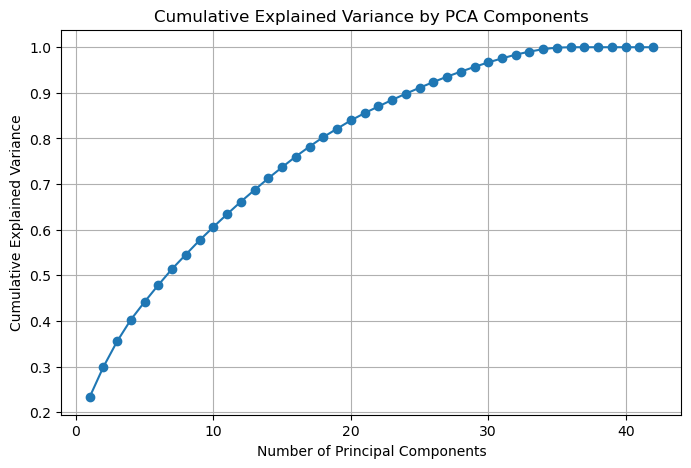

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance by PCA Components")
plt.grid(True)
plt.show()

In [30]:
n_components_90 = np.argmax(cumulative_variance >= 0.90) + 1
print("Number of components to explain at least 90% variance:", n_components_90)

Number of components to explain at least 90% variance: 25


In [31]:
pca = PCA(n_components=n_components_90)
pca_result = pca.fit_transform(df_scaled)

In [32]:
pca_columns = [f"PC{i+1}" for i in range(n_components_90)]
df_pca = pd.DataFrame(pca_result, columns=pca_columns)

df_pca.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC16,PC17,PC18,PC19,PC20,PC21,PC22,PC23,PC24,PC25
0,4.907177,-1.418974,-2.965289,-0.753151,0.612629,-0.293625,-1.282982,1.638147,-0.656006,0.407987,...,0.140435,-0.303917,0.057119,-0.947692,-1.322367,1.111815,0.971972,-0.865267,0.275996,1.236291
1,-3.354716,1.385584,1.575333,-0.394420,1.506318,-0.386198,-1.223970,1.212495,-0.821722,0.691171,...,-0.414635,0.386373,1.025141,-0.648809,-0.540764,-0.036193,-0.010585,0.013301,0.135305,-0.025436
2,2.062370,0.504277,-0.171468,-1.487176,-0.150382,-0.809605,-0.949496,-1.740987,-0.271908,-0.466245,...,-0.240833,-0.482000,-0.935036,0.020496,0.512166,0.328800,0.159581,-0.386396,-0.324635,-0.109717
3,-3.143381,2.195761,0.071298,-0.402530,1.245851,-0.592548,-0.805678,-1.067134,1.048277,-0.660442,...,0.299530,-0.313497,-1.060436,0.224584,0.148540,-0.199493,-0.008380,-0.092460,-0.435390,-0.309790
4,-0.622519,0.982650,1.523614,-0.071738,-0.409641,0.818106,1.633375,1.911472,1.184466,-1.468825,...,0.396227,0.058866,-1.560077,1.096548,-0.399190,0.661514,-0.134693,-0.360804,0.183861,0.787601


In [33]:
print("Shape of PCA-transformed dataset:", df_pca.shape)

Shape of PCA-transformed dataset: (2026, 25)


In [34]:
print("Explained variance ratio of selected components:")
print(pca.explained_variance_ratio_)

print("\nTotal explained variance:")
print(pca.explained_variance_ratio_.sum())

Explained variance ratio of selected components:
[0.23267863 0.06621028 0.05606879 0.04763893 0.03901539 0.03708714
 0.03520641 0.0315148  0.03133497 0.02902499 0.02812935 0.02738551
 0.02573518 0.02565216 0.02415799 0.02357906 0.02183001 0.02074196
 0.01835243 0.01812873 0.01593551 0.0146648  0.01436889 0.01358702
 0.01306761]

Total explained variance:
0.9110965124390784


#####I will keep the PCA output separately for analysis and clustering purposes.


In [35]:
df_pca.to_csv("data_pca.csv", index=False)
print("Saved as data_pca.csv")

Saved as data_pca.csv


##2.5 Discretization

In [36]:
print("Shape of df_before_scaling:", df_before_scaling.shape)
df_before_scaling.head()

Shape of df_before_scaling: (2026, 42)


,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow
0,58138.0,0,0,58,635,88,546,172,88,88,...,False,False,True,False,False,False,False,True,False,False
1,46344.0,1,1,38,11,1,6,2,1,6,...,False,False,True,False,False,False,False,True,False,False
2,71613.0,0,0,26,426,49,127,111,21,42,...,False,False,True,False,False,False,False,False,True,False
3,26646.0,1,0,26,11,4,20,10,3,5,...,False,False,True,False,False,False,False,False,True,False
4,58293.0,1,0,94,173,43,118,46,27,15,...,False,False,False,False,True,False,True,False,False,False


####I'll work on Age, Income and Total Spending

In [37]:
df_before_scaling[["Age", "Income", "Total_Spending"]].describe()

,Age,Income,Total_Spending
count,2026.000000,2026.000000,2026.000000
mean,57.111056,51931.971866,607.439289
std,11.654661,21095.775317,603.431703
min,30.000000,1730.000000,5.000000
25%,49.000000,35461.500000,69.000000
50%,56.000000,51533.000000,396.500000
75%,67.000000,68480.750000,1047.750000
max,86.000000,118423.500000,2525.000000


For Age:
- Young
- Middle_Age
- Senior

In [38]:
df_before_scaling["Age_Group"] = pd.qcut(
    df_before_scaling["Age"],
    q=3,
    labels=["Young", "Middle_Age", "Senior"],
    duplicates="drop"
)

df_before_scaling["Age_Group"].value_counts()

Age_Group
Young         708
Senior        671
Middle_Age    647
Name: count, dtype: int64

For Income:
- Low
- Medium
- High

In [39]:
df_before_scaling["Income_Level"] = pd.qcut(
    df_before_scaling["Income"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)

df_before_scaling["Income_Level"].value_counts()

Income_Level
High      676
Low       675
Medium    675
Name: count, dtype: int64

For Total_Spendings:
- Low
- Medium
- High

In [40]:
df_before_scaling["Spending_Level"] = pd.qcut(
    df_before_scaling["Total_Spending"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)

df_before_scaling["Spending_Level"].value_counts()

Spending_Level
High      676
Low       675
Medium    675
Name: count, dtype: int64

In [41]:
df_before_scaling[[
    "Age", "Age_Group",
    "Income", "Income_Level",
    "Total_Spending", "Spending_Level"
]].head(10)

,Age,Age_Group,Income,Income_Level,Total_Spending,Spending_Level
0,69,Senior,58138.0,Medium,1617,High
1,72,Senior,46344.0,Medium,27,Low
2,61,Middle_Age,71613.0,High,776,Medium
3,42,Young,26646.0,Low,53,Low
4,45,Young,58293.0,Medium,422,Medium
5,59,Middle_Age,62513.0,Medium,716,Medium
6,55,Middle_Age,55635.0,Medium,590,Medium
7,41,Young,33454.0,Low,169,Medium
8,52,Middle_Age,30351.0,Low,46,Low
9,76,Senior,5648.0,Low,49,Low


#####Convert bool columns in encoded data to integers

In [42]:
bool_cols = df_encoded.select_dtypes(include=["bool"]).columns.tolist()
print("Boolean columns:", bool_cols)

df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)
print(df_encoded.dtypes.value_counts())

Boolean columns: ['Education_2n Cycle', 'Education_Basic', 'Education_Graduation', 'Education_Master', 'Education_PhD', 'Marital_Status_Divorced', 'Marital_Status_Married', 'Marital_Status_Single', 'Marital_Status_Together', 'Marital_Status_Widow']
int64      26
int32      12
float64     4
Name: count, dtype: int64


##Combine encoded data + PCA + discretized features

In [43]:
discretized_cols = df_before_scaling[["Age_Group", "Income_Level", "Spending_Level"]].reset_index(drop=True)
df_encoded_reset = df_encoded.reset_index(drop=True)
df_pca_reset = df_pca.reset_index(drop=True)

df_preprocessed = pd.concat([df_encoded_reset, df_pca_reset, discretized_cols], axis=1)
df_preprocessed.head()

,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,...,PC19,PC20,PC21,PC22,PC23,PC24,PC25,Age_Group,Income_Level,Spending_Level
0,58138.0,0,0,58,635,88,546,172,88,88,...,-0.947692,-1.322367,1.111815,0.971972,-0.865267,0.275996,1.236291,Senior,Medium,High
1,46344.0,1,1,38,11,1,6,2,1,6,...,-0.648809,-0.540764,-0.036193,-0.010585,0.013301,0.135305,-0.025436,Senior,Medium,Low
2,71613.0,0,0,26,426,49,127,111,21,42,...,0.020496,0.512166,0.328800,0.159581,-0.386396,-0.324635,-0.109717,Middle_Age,High,Medium
3,26646.0,1,0,26,11,4,20,10,3,5,...,0.224584,0.148540,-0.199493,-0.008380,-0.092460,-0.435390,-0.309790,Young,Low,Low
4,58293.0,1,0,94,173,43,118,46,27,15,...,1.096548,-0.399190,0.661514,-0.134693,-0.360804,0.183861,0.787601,Young,Medium,Medium


In [44]:
print("Final preprocessed shape:", df_preprocessed.shape)
print("\nFinal columns:")
print(df_preprocessed.columns.tolist())

Final preprocessed shape: (2026, 70)

Final columns:
['Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Response', 'Total_Spending', 'Total_Purchases', 'Average_Spend', 'Family_Size', 'Age', 'Engagement', 'Spending_Ratio', 'Customer_Days', 'Customer_Year', 'Customer_Month', 'Education_2n Cycle', 'Education_Basic', 'Education_Graduation', 'Education_Master', 'Education_PhD', 'Marital_Status_Divorced', 'Marital_Status_Married', 'Marital_Status_Single', 'Marital_Status_Together', 'Marital_Status_Widow', 'PC1', 'PC2', 'PC3', 'PC4', 'PC5', 'PC6', 'PC7', 'PC8', 'PC9', 'PC10', 'PC11', 'PC12', 'PC13', 'PC14', 'PC15', 'PC16', 'PC17', 'PC18', 'PC19', 'PC20', 'PC21', 'PC22', 'PC23', 'PC24', 'PC25', 'Age_Group',

In [45]:
print("Total missing values in final dataset:", df_preprocessed.isnull().sum().sum())

Total missing values in final dataset: 0


In [46]:
df_preprocessed.dtypes.value_counts()

float64     29
int64       26
int32       12
category     2
category     1
Name: count, dtype: int64

In [47]:
df_preprocessed.to_csv("data_preprocessed.csv", index=False)
print("Saved final file as data_preprocessed.csv")

Saved final file as data_preprocessed.csv
